In [3]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print(gpus)

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [32]:
(x_train, y_train), (x_test, y_test) = df = tf.keras.datasets.cifar10.load_data()
labels = {0:    "airplane",
1:	"automobile",
2:	"bird",
3:	"cat",
4:	"deer",
5:	"dog",
6:	"frog",
7:	"horse",
8:	"ship",
9:	"truck"}

# EDA:

In [10]:
print('Shape of x_train is {}'.format(x_train.shape))
print('Shape of x_test is {}'.format(x_test.shape)) 
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

Shape of x_train is (50000, 32, 32, 3)
Shape of x_test is (10000, 32, 32, 3)
Shape of y_train is (50000, 1)
Shape of y_test is (10000, 1)


### Examining Image Dimensions:

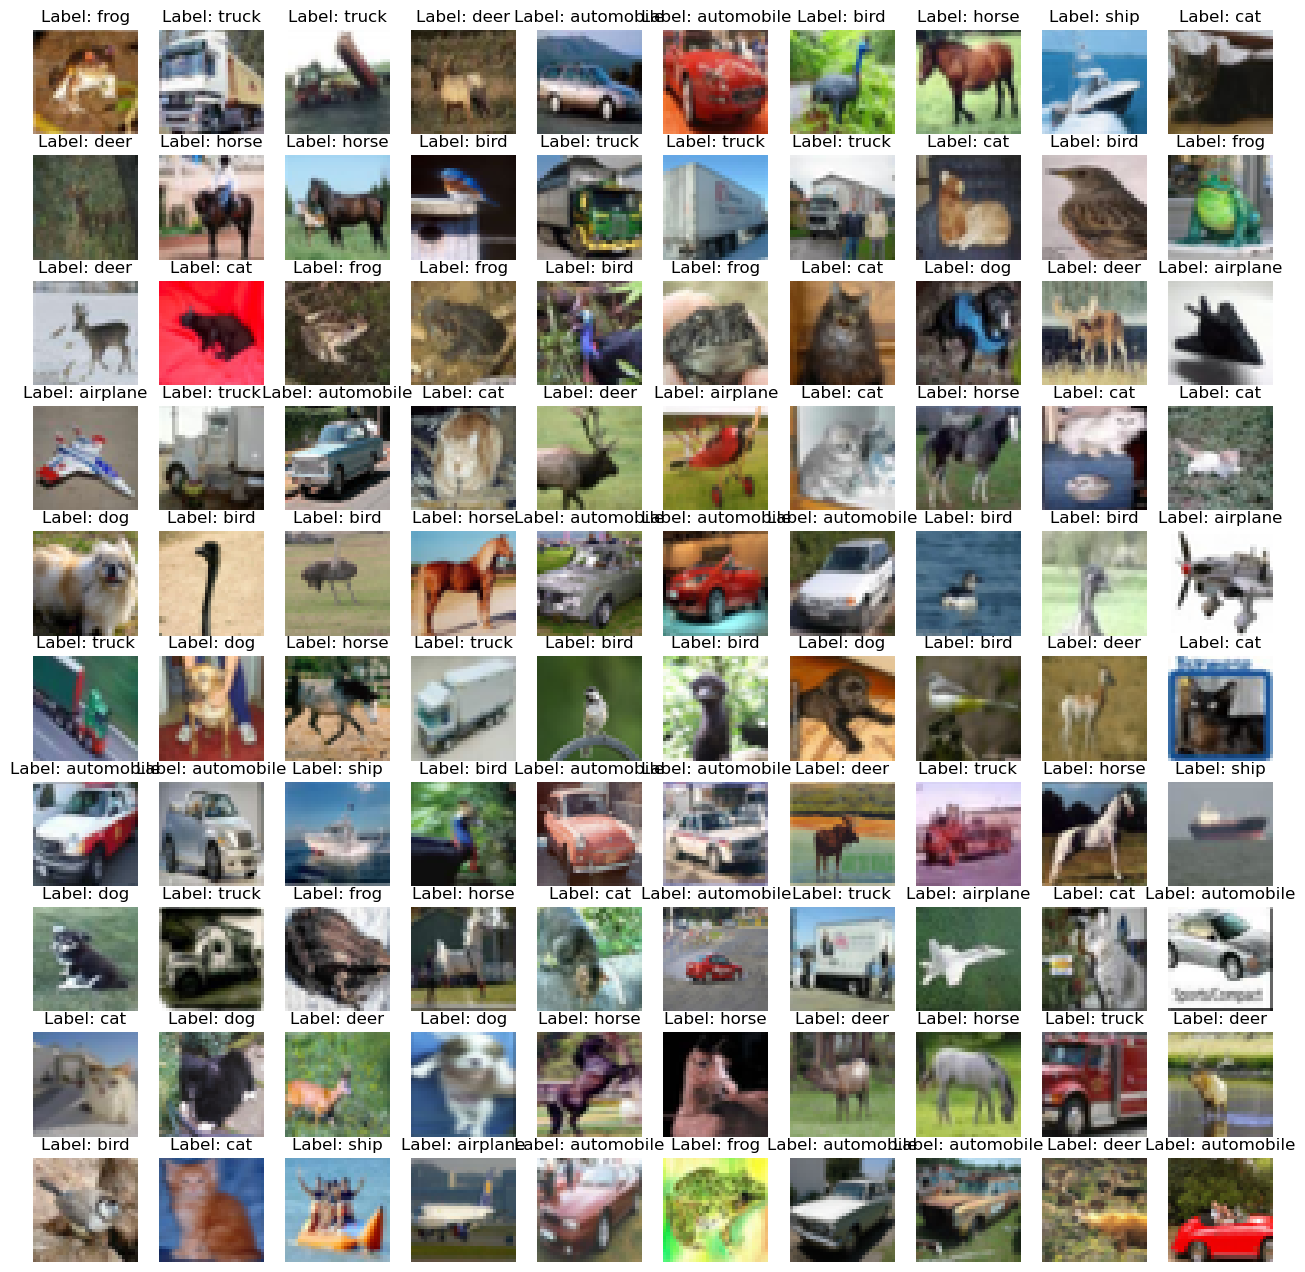

In [16]:
# Reshape to image dimensions (e.g., 32x32 for CIFAR-10)
pixels = x_train.reshape(x_train.shape[0], 32, 32, 3)  # Reshape to (num_samples, height, width, channels)
nolabels = y_train.flatten()  # Flatten labels to 1D array
nir = 10 # Number of images to display in each row and column
ax = plt.figure(figsize=(16, 16))
for index in range((nir*nir)):
    single_image = pixels[index]
    ax = plt.subplot(nir, nir, index+1)
    plt.imshow(single_image, cmap='gray')   
    plt.title(f"Label: {labels.get(nolabels[index])}")
    plt.axis('off')

Checking Class balance:

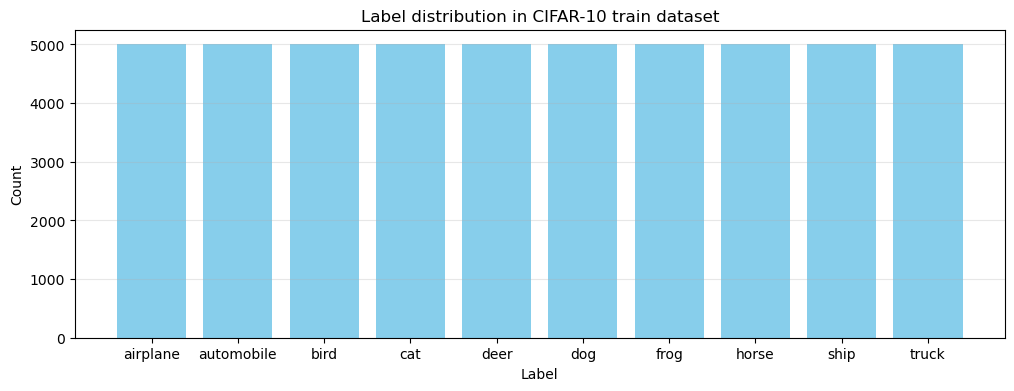

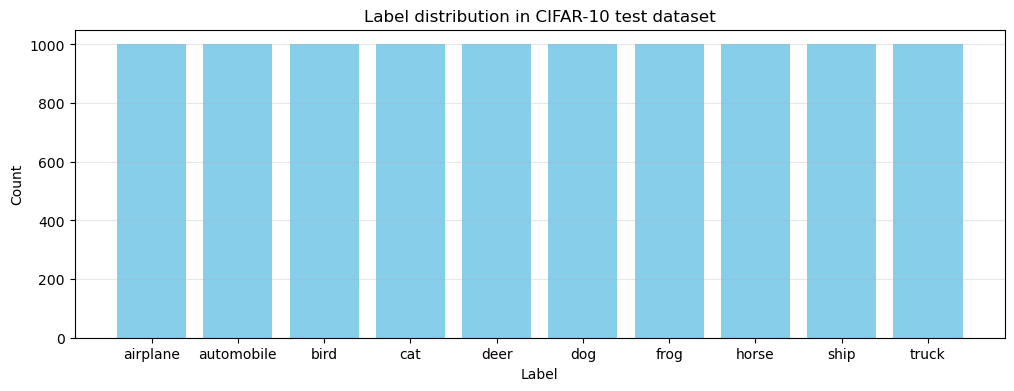

In [33]:
plt.figure(figsize=(12, 4))
plt.bar(labels.values(), np.bincount(y_train.flatten()), color='skyblue')
plt.title('Label distribution in CIFAR-10 train dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(labels.values(), np.bincount(y_test.flatten()), color='skyblue')
plt.title('Label distribution in CIFAR-10 test dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Calculating stats of each of the channels for imgs:


In [41]:
print(f"Channel Means (R,G,B)for trian: {x_train.mean(axis=(0, 1, 2))}, Channel Std for train (R,G,B): {x_train.std(axis=(0, 1, 2))}")
print(f"Channel Means (R,G,B)for test: {x_test.mean(axis=(0, 1, 2))}, Channel Std for test (R,G,B): {x_test.std(axis=(0, 1, 2))}")

Channel Means (R,G,B)for trian: [125.30691805 122.95039414 113.86538318], Channel Std for train (R,G,B): [62.99321928 62.08870764 66.70489964]
Channel Means (R,G,B)for test: [126.02464141 123.7085042  114.85431865], Channel Std for test (R,G,B): [62.89639135 61.93752718 66.7060564 ]


It appears as if the blue channel has a lower intensity than the others throughout the dataset. This may cause some bias during training.

Text(0.5, 0, 'Pixel Intensity')

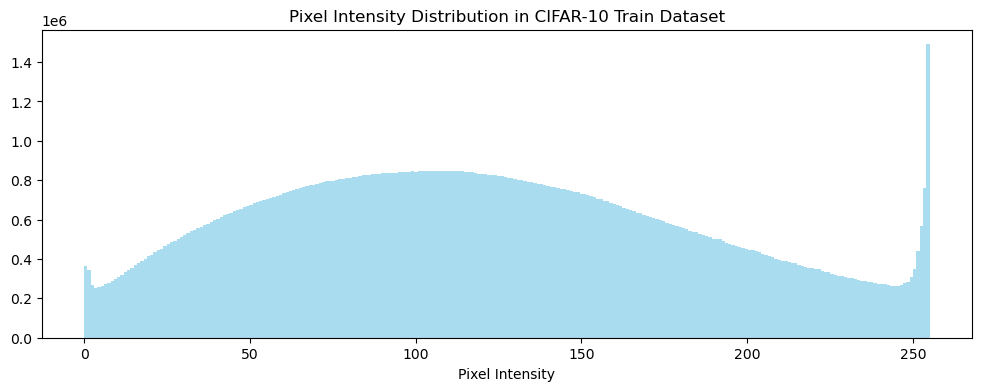

In [46]:
plt.figure(figsize=(12, 4))
plt.hist(x_train.flatten(), bins=256, color='skyblue', alpha=0.7)
plt.title('Pixel Intensity Distribution in CIFAR-10 Train Dataset')
plt.xlabel('Pixel Intensity')

It seems as if there is a sharp spike of pixels that lean towards pure white. This can be explained by looking at the above graphed images;
- Image Clipping (Sensor Saturation): Many of the 32x32 images in the dataset were captured under bright lighting, sunlight, or studio conditions. When a region of an object is brightly illuminated, the optical sensor in the camera records the light as maxed out. The sensor's data "clips" (or saturates) at the highest possible 8-bit integer value (255), leaving a cluster of maximum-intensity pixels.
- Specular Reflections: Shiny surfaces (like the hoods of cars, polished ship hulls, or animal eyes) create specular highlights. These direct reflections of a light source bounce brightly into the camera, appearing as pure white in an image and grouping pixels at the upper limits.
- Background Bias: Several classes in CIFAR-10 (like airplanes, cars, and certain animals) feature images photographed against artificial studio backdrops. These unicolor, uniform backgrounds are frequently set to pure white (R: 255, G: 255, B: 255) to cleanly isolate the foreground object, producing a massive accumulation of pixels at the 255 boundary.